# Mini-TP 5 — Federa tu modelo y mide el trade-off (starter)

**Operaciones de Aprendizaje Automático II · CEIA – FIUBA · Entrega individual, esta semana**

Corre una **simulación federada** con FedAvg y **analiza el trade-off privacidad vs performance**. Completa las celdas marcadas con `# TODO`.

**Qué debes entregar**
1. Reparte un dataset (**el tuyo** o el provisto) entre **K clientes** y corre FedAvg.
2. Compara la accuracy **federada** contra la **centralizada**.
3. Repite con una partición **non-IID** y observa la diferencia (grafica accuracy vs ronda).
4. **Analiza el trade-off:** ¿cuánto accuracy “cuesta” no mover el dato? ¿y sumar privacidad?
5. **(Opcional)** Agrega ruido (privacidad diferencial simple) y mide el impacto.

**Se evalúa:** que corra de punta a punta; FedAvg bien implementado; comparación IID / non-IID / centralizado; y la reflexión sobre el trade-off.

> Apóyate en `federated_tutorial.ipynb`. Entorno uv: `uv add scikit-learn numpy matplotlib`.

In [ ]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-learn", "numpy", "matplotlib"])
print("Listo.")

## 1. Datos y modelo

Puedes usar **tu** dataset (el de tu modelo) o el `digits` provisto para practicar la mecánica. El modelo softmax de abajo sirve como base; si usas tu modelo, adapta las funciones.

In [12]:
import io
import re

import boto3
import numpy as np
import pandas as pd
from botocore.client import Config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

rng = np.random.RandomState(0)

# --- Descarga el mismo dataset crudo con el que se entrenó xgb_best (TP integrador) ---
_s3 = boto3.client(
    "s3",
    endpoint_url="http://localhost:9000",
    aws_access_key_id="minioadmin",
    aws_secret_access_key="minioadmin123",
    config=Config(signature_version="s3v4"),
    region_name="us-east-1",
)
_buffer = io.BytesIO()
_s3.download_fileobj("raw-data", "car_details_v3.csv", _buffer)
_buffer.seek(0)
df_raw = pd.read_csv(_buffer).drop_duplicates().reset_index(drop=True)
print("Dataset crudo:", df_raw.shape)

# --- Mismo feature engineering que common/preprocessing.py (TP integrador), ---
# --- inline acá para no depender de ese paquete desde este notebook. ---
REFERENCE_YEAR = 2020
MARCAS_DOS_PALABRAS = {"Land Rover", "Ashok Leyland"}
OWNER_MAP = {
    "First Owner": 1, "Second Owner": 2, "Third Owner": 3,
    "Fourth & Above Owner": 4, "Test Drive Car": 5,
}
NULL_CHECK_COLUMNS = ["mileage_value", "engine_value", "max_power_value", "torque_nm", "seats"]
KM_OUTLIER_THRESHOLD = 1_000_000
TORQUE_KGM_TO_NM = 9.80665
TOP_BRAND_COUNT = 10
NUMERIC_FEATURES = ["car_age", "km_driven", "mileage_value", "engine_value",
                     "max_power_value", "torque_nm", "seats", "owner_num"]
BINARY_FEATURES = ["is_manual", "is_individual"]


def extraer_marca_modelo(name):
    if pd.isna(name):
        return pd.Series([np.nan, np.nan, np.nan])
    tokens = name.strip().split()
    dos = " ".join(tokens[:2])
    if dos in MARCAS_DOS_PALABRAS:
        marca, modelo = dos, (tokens[2] if len(tokens) > 2 else np.nan)
    else:
        marca, modelo = tokens[0], (tokens[1] if len(tokens) > 1 else np.nan)
    return pd.Series([marca, modelo, np.nan])


def split_num_unidad(serie):
    num = pd.to_numeric(serie.astype(str).str.extract(r"(-?[\d.]+)")[0], errors="coerce")
    return num, None


def parse_torque(t):
    if pd.isna(t):
        return pd.Series([np.nan, np.nan])
    s = str(t)
    m_val = re.search(r"([\d.]+)", s)
    val = float(m_val.group(1)) if m_val else np.nan
    unit = "kgm" if "kgm" in s.lower() else ("Nm" if "nm" in s.lower() else np.nan)
    return pd.Series([val, unit])


def extraer_columnas_tecnicas(df):
    df = df.copy()
    df[["brand", "model", "_r"]] = df["name"].apply(extraer_marca_modelo)
    df["mileage_value"], _ = split_num_unidad(df["mileage"])
    df["engine_value"], _ = split_num_unidad(df["engine"])
    df["max_power_value"], _ = split_num_unidad(df["max_power"])
    df[["torque_value", "torque_unit"]] = df["torque"].apply(parse_torque)
    df["torque_nm"] = np.where(df["torque_unit"] == "kgm",
                                df["torque_value"] * TORQUE_KGM_TO_NM, df["torque_value"])
    df["car_age"] = REFERENCE_YEAR - df["year"]
    return df


df = extraer_columnas_tecnicas(df_raw)
df = df.dropna(subset=NULL_CHECK_COLUMNS).reset_index(drop=True)
df = df[df["km_driven"] <= KM_OUTLIER_THRESHOLD].copy()

df["owner_num"] = df["owner"].map(OWNER_MAP)
df["is_manual"] = (df["transmission"] == "Manual").astype(int)
df["is_individual"] = (df["seller_type"] == "Individual").astype(int)
top_brands = df["brand"].value_counts().head(TOP_BRAND_COUNT).index.tolist()
df["brand_grouped"] = df["brand"].where(df["brand"].isin(top_brands), "Other")
df_enc = pd.get_dummies(df, columns=["fuel", "brand_grouped"], drop_first=True, dtype=int)

features_fuel = [c for c in df_enc.columns if c.startswith("fuel_")]
features_brand = [c for c in df_enc.columns if c.startswith("brand_grouped_")]
all_features = NUMERIC_FEATURES + BINARY_FEATURES + features_fuel + features_brand

# Mismo target que xgb_best: log1p(precio) — predict.py aplica np.expm1 al servir.
X = df_enc[all_features].to_numpy(dtype=float)
y = np.log1p(df_enc["selling_price"].to_numpy(dtype=float))
X = StandardScaler().fit_transform(X)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0)
N_FEAT = X.shape[1]

# --- Modelo: regresión lineal (SGD sobre MSE) — xgb_best es un regresor, no un
# clasificador, así que acá no hay softmax/accuracy: se federa un regresor simple
# y se mide error (RMSE), coherente con lo que el modelo real predice (precio). ---
def init_modelo():
    return np.zeros(N_FEAT), 0.0

def paso_sgd(w, b, X, y, lr):
    pred = X @ w + b
    err = pred - y                      # residuo, no probabilidad
    grad_w = X.T @ err / len(y)
    grad_b = err.mean()
    return w - lr * grad_w, b - lr * grad_b

def rmse(w, b, X=Xte, y=yte):
    pred = X @ w + b
    return float(np.sqrt(np.mean((pred - y) ** 2)))

print("Datos:", Xtr.shape, "· features:", N_FEAT, "· target: log1p(selling_price)")


Dataset crudo: (6926, 13)
Datos: (5036, 23) · features: 23 · target: log1p(selling_price)


## 2. Centralizado (línea de base)

In [14]:
def entrenar_centralizado(epocas=500, lr=0.01):
    w,b=init_modelo()
    for _ in range(epocas): w,b=paso_sgd(w,b,Xtr,ytr,lr)
    return w,b
wc,bc=entrenar_centralizado(); rmse_central=rmse(wc,bc)
print(f"RMSE centralizado (log-precio): {rmse_central:.3f}")

RMSE centralizado (log-precio): 0.274


## 3. FedAvg

Completa el entrenamiento local y la agregación (o reúsalos del tutorial).

In [15]:
def entrenar_local(w_glob, b_glob, Xc, yc, epocas=50, lr=0.01):
    w,b = w_glob.copy(), b_glob
    for _ in range(epocas):
        w,b = paso_sgd(w,b,Xc,yc,lr)
    return w, b, len(Xc)

def fedavg(actualizaciones):
    # promedio PONDERADO por nº de datos de cada cliente (no un promedio simple:
    # un cliente con más datos locales pesa más en el modelo global)
    n = sum(nk for _,_,nk in actualizaciones)
    w = sum((nk/n)*wk for wk,_,nk in actualizaciones)
    b = sum((nk/n)*bk for _,bk,nk in actualizaciones)
    return w, b

def federado(clientes, R=20, frac=0.4, epocas=50, lr=0.01, sigma=0.0):
    w,b=init_modelo(); K,m=len(clientes),max(1,int(frac*len(clientes))); hist=[]
    for _ in range(R):
        sel=rng.choice(K,m,replace=False)
        ups=[entrenar_local(w,b,*clientes[i][:2],epocas,lr) for i in sel]
        w,b=fedavg(ups)
        if sigma > 0:  # privacidad diferencial simple (punto 6): ruido gaussiano post-agregación
            w = w + rng.normal(0, sigma, size=w.shape)
            b = b + rng.normal(0, sigma)
        hist.append(rmse(w,b))
    return w,b,hist
print("FedAvg listo.")

FedAvg listo.


## 4. Particiones IID y non-IID

In [16]:
def particionar_iid(K):
    idx=rng.permutation(len(Xtr)); return [(Xtr[c],ytr[c]) for c in np.array_split(idx,K)]

def particionar_no_iid(K, shards_por_cliente=2):
    # Para regresión no hay "clases": ordenar por el target (precio) y repartir en
    # shards simula que cada cliente ve un rango de precios distinto (ej. concesionarias
    # que solo venden autos baratos vs solo autos caros) — el análogo de non-IID por clase.
    order=np.argsort(ytr); shards=np.array_split(order,K*shards_por_cliente); rng.shuffle(shards)
    out=[]
    for k in range(K):
        idx=np.concatenate(shards[k*shards_por_cliente:(k+1)*shards_por_cliente]); out.append((Xtr[idx],ytr[idx]))
    return out

K = 5
_,_,hist_iid  = federado(particionar_iid(K))
_,_,hist_niid = federado(particionar_no_iid(K))
print(f"central={rmse_central:.3f} | IID={hist_iid[-1]:.3f} | non-IID={hist_niid[-1]:.3f}  (RMSE en log-precio, menor=mejor)")

central=0.274 | IID=0.257 | non-IID=0.265  (RMSE en log-precio, menor=mejor)


## 5. Grafica accuracy vs ronda

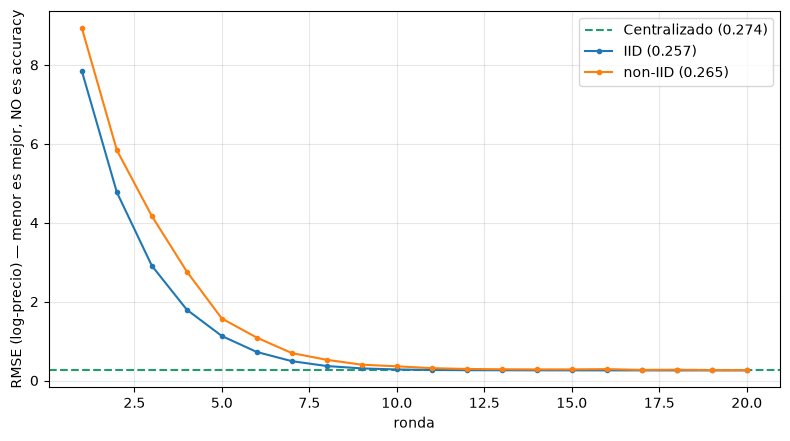

In [17]:
import matplotlib.pyplot as plt

# OJO: acá NO se grafica accuracy (eso era para clasificación de dígitos, el ejemplo
# original). Nuestro modelo es un regresor (predice precio), así que medimos RMSE
# (error), no accuracy. A diferencia de accuracy (más alto = mejor), en RMSE
# menor = mejor: el objetivo es que la curva BAJE, no que suba.
plt.figure(figsize=(8,4.5))
plt.axhline(rmse_central, ls="--", color="#1F9D6B", label=f"Centralizado ({rmse_central:.3f})")
plt.plot(range(1,len(hist_iid)+1),  hist_iid,  "-o", ms=3, label=f"IID ({hist_iid[-1]:.3f})")
plt.plot(range(1,len(hist_niid)+1), hist_niid, "-o", ms=3, label=f"non-IID ({hist_niid[-1]:.3f})")
plt.xlabel("ronda"); plt.ylabel("RMSE (log-precio) — menor es mejor, NO es accuracy")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 6. (Opcional) Privacidad diferencial

Agrega ruido a los pesos agregados y mide cómo cae la accuracy.

sigma=0.0   RMSE final=0.256
sigma=0.05  RMSE final=0.413
sigma=0.1   RMSE final=0.557
sigma=0.2   RMSE final=1.259


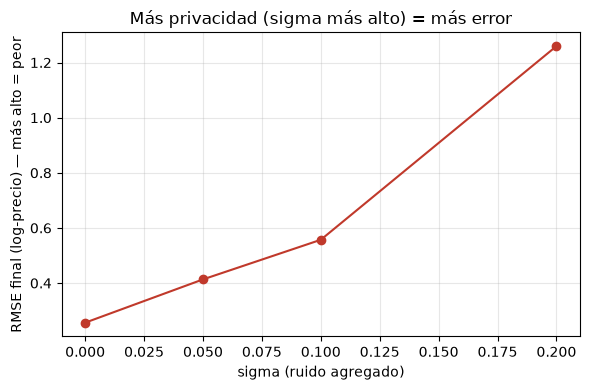

In [18]:
# Privacidad diferencial simple: después de cada agregación (fedavg), se le suma
# ruido aleatorio (gaussiano) a los pesos del modelo global. Esto dificulta que
# alguien "adivine" los datos originales de un cliente mirando los pesos, pero
# a mayor ruido (sigma), peor queda el modelo.
#
# OJO: acá medimos RMSE (error), no accuracy. Con RMSE, más alto = peor modelo
# (más ruido = más error = peor).
sigmas = [0.0, 0.05, 0.1, 0.2]
rmse_por_sigma = []

for sigma in sigmas:
    _, _, hist_sigma = federado(particionar_iid(K), sigma=sigma)
    rmse_por_sigma.append(hist_sigma[-1])
    print(f"sigma={sigma:<5} RMSE final={hist_sigma[-1]:.3f}")

plt.figure(figsize=(6,4))
plt.plot(sigmas, rmse_por_sigma, "-o", color="#C0392B")
plt.xlabel("sigma (ruido agregado)")
plt.ylabel("RMSE final (log-precio) — más alto = peor")
plt.title("Más privacidad (sigma más alto) = más error")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

### Reflexión (completa)

_TODO: 4–6 líneas._
- ¿Cuánta accuracy se pierde al federar (IID) frente al centralizado? ¿Y con non-IID?
- ¿Qué observaste en la **estabilidad** de la curva non-IID y por qué?
- ¿Qué medida de privacidad agregarías en tu caso y qué costo tendría?
- ¿En tu proyecto, el federado sería **orgánico** o **forzado**? Justifica.

**1. ¿Cuánto error se pierde al federar?**
Centralizado: RMSE 0.274. IID: RMSE 0.257. Non-IID: RMSE 0.265. En este caso, federar con partición IID no empeoró el resultado, de hecho dio un poquito mejor que el centralizado (los clientes en conjunto terminan entrenando más pasos en total). Con non-IID el error sube un poco respecto a IID (0.265 vs 0.257), pero sigue estando cerca del centralizado: la pérdida por repartir los datos entre clientes fue chica en este dataset.

**2. ¿Qué pasa con la curva non-IID?**
La curva non-IID se mueve más entre rondas que la IID, en vez de bajar derecho. Esto pasa porque en cada ronda se eligen clientes al azar, y como cada cliente non-IID tiene datos muy distintos (por ejemplo, solo autos caros o solo baratos), el modelo global "salta" según qué clientes participaron esa ronda.

**3. ¿Qué medida de privacidad usaría y qué cuesta?**
Usaría privacidad diferencial simple: sumar ruido a los pesos después de cada agregación. El costo se ve clarísimo en los números: sin ruido (sigma=0) el RMSE es 0.256, con sigma=0.05 sube a 0.413, con sigma=0.1 a 0.557, y con sigma=0.2 se dispara a 1.259. Es decir, el error casi se quintuplica al pasar de sin ruido a sigma=0.2. Un poco de ruido ya cuesta caro en precisión, así que hay que elegir sigma con cuidado.

**4. ¿Federado orgánico o forzado en mi proyecto?**
En mi caso (predecir precio de autos usados) el federado sería más bien forzado: hoy el dataset ya está centralizado en un solo lugar, no nace repartido entre dueños distintos. Sería orgánico si, por ejemplo, cada concesionaria tuviera sus propios datos de ventas y no quisiera compartirlos con las demás: ahí sí federar tendría una razón real, no solo de práctica.